In [18]:
import sys
import os

# Add project root
sys.path.append(os.path.abspath(".."))

from src.monte_carlo import run_simulation

import numpy as np
import matplotlib.pyplot as plt



In [19]:
params = {
    "S0": 2000.0,
    "mu": 0.0,
    "sigma": 0.6,   # base value (will be overwritten)
    "Q": 1.0,
    "B0": 800.0,
    "LT": 0.8,
    "r_b": 0.02,
    "T": 1.0,
    "N": 252,
    "n_paths": 5000,
}


In [20]:
def compute_sigma_curve(base_params, sigma_grid):
    probs = []

    for sigma in sigma_grid:
        params = base_params.copy()
        params["sigma"] = sigma

        results = run_simulation(params)
        probs.append(results["liquidation_prob"])

    return np.array(probs)



In [21]:
sigma_grid = np.linspace(0.1, 1.0, 12)

probs = compute_sigma_curve(params, sigma_grid)

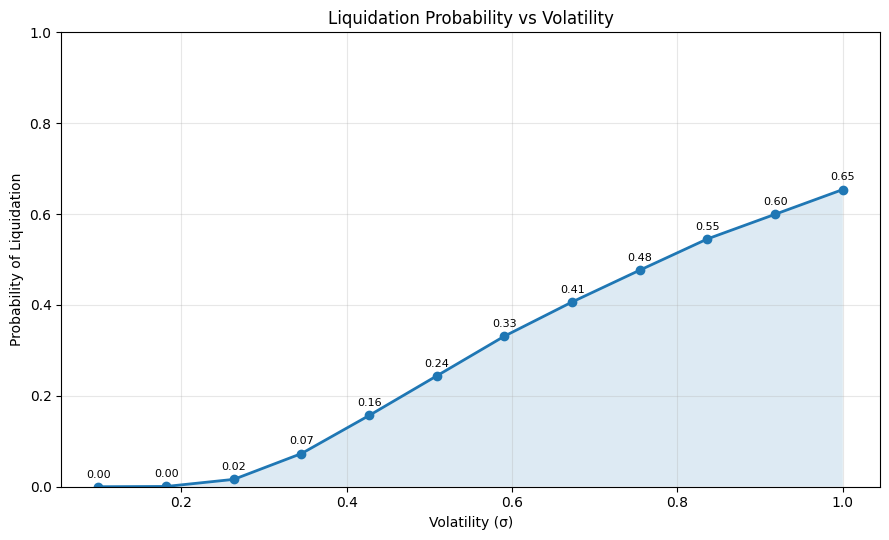

In [22]:
import os
os.makedirs("../figures", exist_ok=True)

plt.figure(figsize=(9, 5.5))

plt.plot(
    sigma_grid,
    probs,
    marker="o",
    linewidth=2,
)

plt.fill_between(sigma_grid, probs, alpha=0.15)

plt.title("Liquidation Probability vs Volatility")
plt.xlabel("Volatility (σ)")
plt.ylabel("Probability of Liquidation")

plt.ylim(0, 1)
plt.grid(alpha=0.3)

# annotate values (optional but nice)
for x, y in zip(sigma_grid, probs):
    plt.text(x, y + 0.02, f"{y:.2f}", ha='center', fontsize=8)

plt.tight_layout()

# ✅ SAVE HERE
plt.savefig(    
    "../figures/fig1_liquidation_probability_vs_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
results = run_simulation(params)

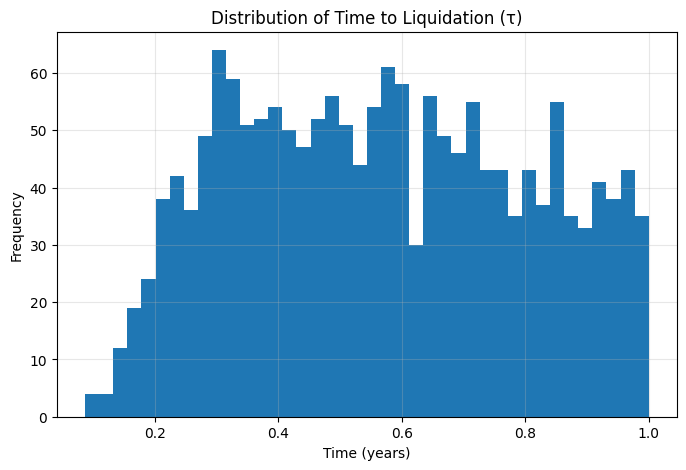

In [24]:
import os
os.makedirs("../figures", exist_ok=True)

tau = results["liquidation_times"]
liquidated = results["liquidated"]

tau_clean = tau[~np.isnan(tau)]

plt.figure(figsize=(8, 5))
plt.hist(tau_clean, bins=40)

plt.title("Distribution of Time to Liquidation (τ)")
plt.xlabel("Time (years)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

# ✅ SAVE HERE
plt.savefig(
    "../figures/fig2_distribution_τ.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

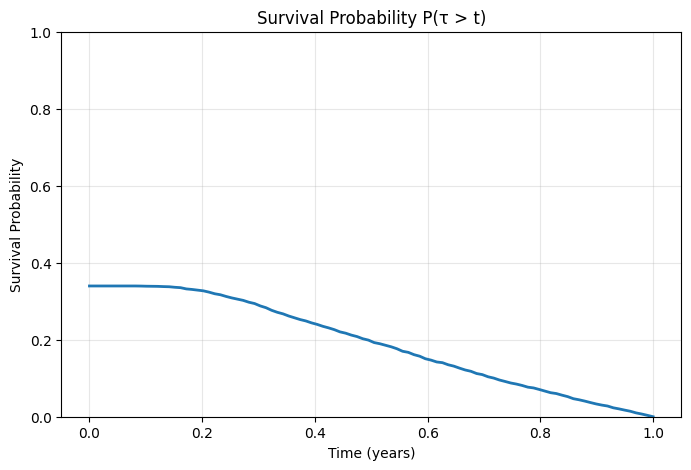

In [25]:
tau = results["liquidation_times"]
t_grid = results["time_grid"]

times = np.linspace(0, t_grid[-1], 100)

survival = [(tau > t).mean() for t in times]

plt.figure(figsize=(8, 5))
plt.plot(times, survival, linewidth=2)

plt.title("Survival Probability P(τ > t)")
plt.xlabel("Time (years)")
plt.ylabel("Survival Probability")

plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.show()

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def plot_full_diagnostics(results, params):
    HF = results["HF_paths"]
    tau = results["liquidation_times"]
    t = results["time_grid"]

    # --- Prepare data ---
    tau_clean = tau[~np.isnan(tau)]
    times = np.linspace(0, t[-1], 100)
    survival = [(tau > x).mean() for x in times]

    # sigma curve
    sigma_grid = np.linspace(0.1, 1.0, 10)
    probs = []
    for sigma in sigma_grid:
        p = params.copy()
        p["sigma"] = sigma
        res = run_simulation(p)
        probs.append(res["liquidation_prob"])

    # --- Figure layout ---
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # =========================
    # (1) HF PATHS
    # =========================
    ax = axes[0, 0]
    n_plot = 25
    idx = np.random.choice(len(HF), n_plot, replace=False)

    HF_plot = HF.copy()

    for i in idx:
        if not np.isnan(tau[i]):
            liq_idx = np.searchsorted(t, tau[i])
            HF_plot[i, liq_idx:] = np.nan

    for i in idx:
        if np.isnan(tau[i]):
            ax.plot(t, HF_plot[i], color="tab:blue", alpha=0.7, linewidth=1)
        else:
            ax.plot(t, HF_plot[i], color="tab:red", linestyle="--", alpha=0.7, linewidth=1)

    ax.axhline(1.0, linestyle="--", color="black", linewidth=1)
    ax.set_title("Health Factor Paths")
    ax.set_xlabel("Time")
    ax.set_ylabel("HF")
    ax.grid(alpha=0.3)

    # =========================
    # (2) TAU DISTRIBUTION
    # =========================
    ax = axes[0, 1]
    ax.hist(tau_clean, bins=40)
    ax.set_title("Time-to-Liquidation Distribution (τ)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3)

    # =========================
    # (3) SURVIVAL CURVE
    # =========================
    ax = axes[1, 0]
    ax.plot(times, survival, linewidth=2)
    ax.set_title("Survival Probability P(τ > t)")
    ax.set_xlabel("Time")
    ax.set_ylabel("Survival Probability")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

    # =========================
    # (4) SIGMA CURVE
    # =========================
    ax = axes[1, 1]
    ax.plot(sigma_grid, probs, marker="o", linewidth=2)
    ax.fill_between(sigma_grid, probs, alpha=0.15)
    ax.set_title("Liquidation Probability vs Volatility")
    ax.set_xlabel("σ")
    ax.set_ylabel("P(Liquidation)")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

    # --- Final layout ---
    plt.suptitle("Aave Liquidation Risk Diagnostics", fontsize=14)
    plt.tight_layout()
    plt.savefig("../figures/aave_liquidation_diagnostics.png", dpi=300)
    plt.show()

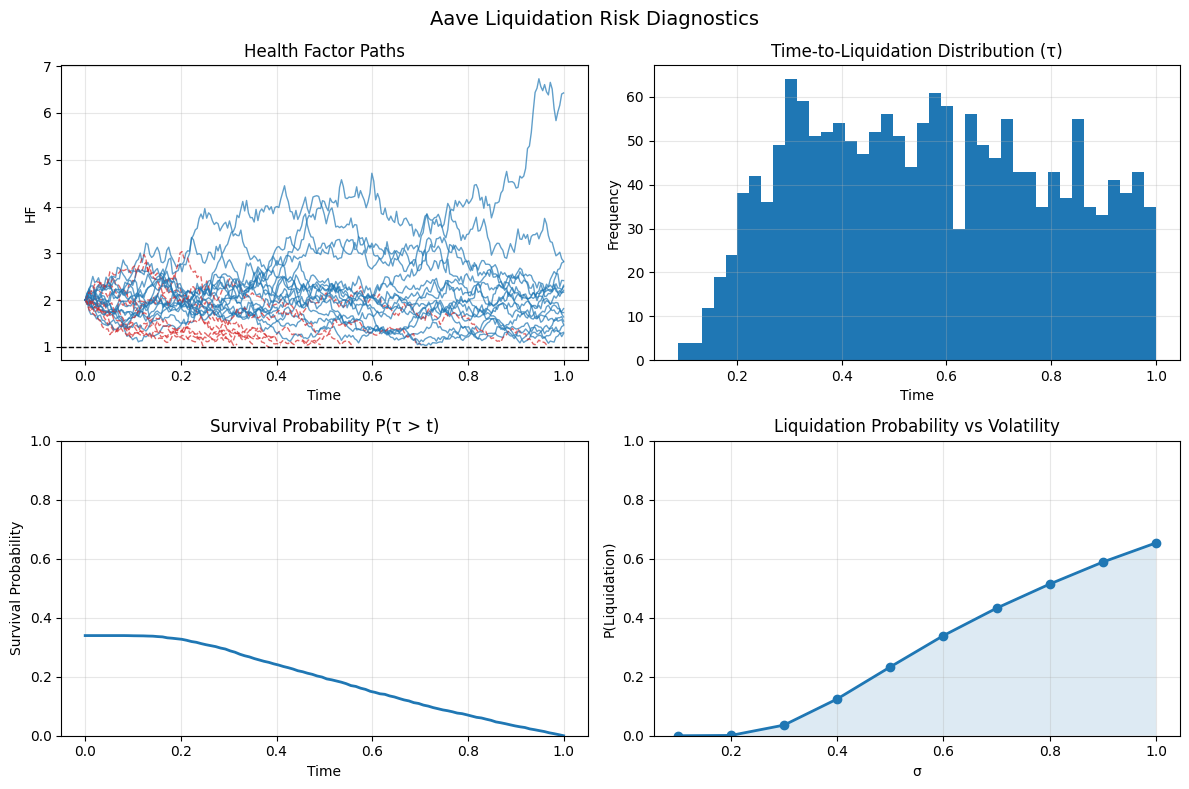

In [27]:
plot_full_diagnostics(results, params)

Initial distance-to-liquidation: 0.6931471805599453


FileNotFoundError: [Errno 2] No such file or directory: 'figures/fig3_distance-to-liquidation_paths.png'

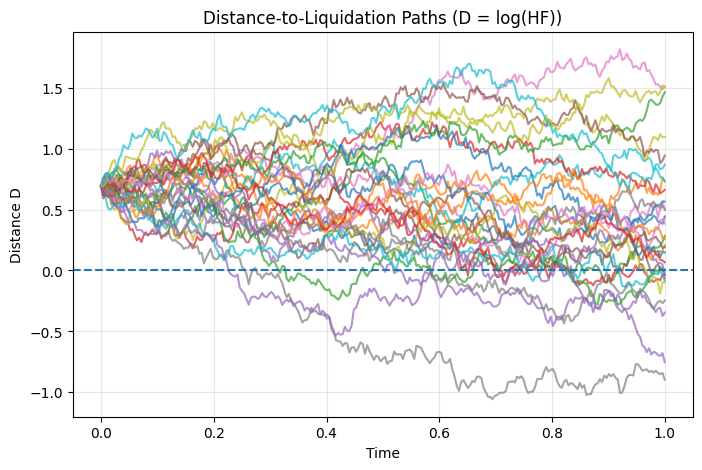

In [ ]:
import os
os.makedirs("../figures", exist_ok=True)

D_paths = np.log(results["HF_paths"])

D0 = np.log(params["Q"] * params["S0"] * params["LT"] / params["B0"])
print("Initial distance-to-liquidation:", D0)

plt.figure(figsize=(8, 5))

n_plot = 30
idx = np.random.choice(len(D_paths), n_plot, replace=False)

for i in idx:
    plt.plot(results["time_grid"], D_paths[i], alpha=0.7)

plt.axhline(0, linestyle="--")  # boundary

plt.title("Distance-to-Liquidation Paths (D = log(HF))")
plt.xlabel("Time")
plt.ylabel("Distance D")

plt.grid(alpha=0.3)

# ✅ SAVE HERE
plt.savefig(
    "../figures/fig3_distance-to-liquidation_paths.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [ ]:
def compute_normalized_distance(params):
    HF0 = params["Q"] * params["S0"] * params["LT"] / params["B0"]
    D0 = np.log(HF0)
    sigma = params["sigma"]
    T = params["T"]

    return D0 / (sigma * np.sqrt(T))



In [ ]:
sigmas = np.linspace(0.2, 1.0, 8)

norm_dist = []
probs = []

for sigma in sigmas:
    p = params.copy()
    p["sigma"] = sigma

    res = run_simulation(p)

    norm_dist.append(compute_normalized_distance(p))
    probs.append(res["liquidation_prob"])

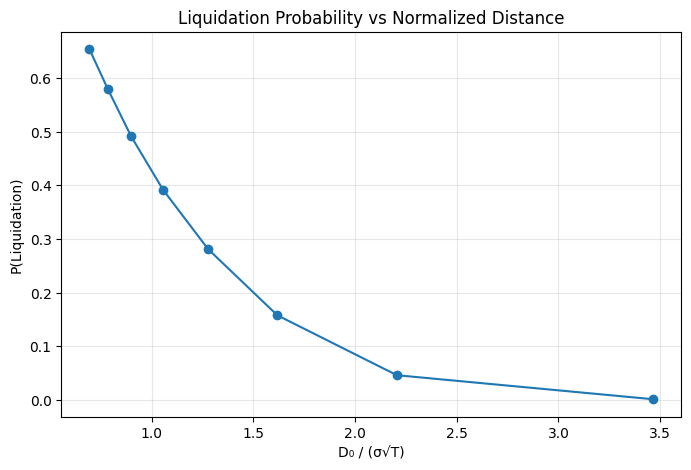

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(norm_dist, probs, marker="o")

plt.title("Liquidation Probability vs Normalized Distance")
plt.xlabel("D₀ / (σ√T)")
plt.ylabel("P(Liquidation)")

plt.grid(alpha=0.3)

# ✅ SAVE HERE
plt.savefig(
    "figures/fig4_liquidation_probability_vs_normalized_distance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

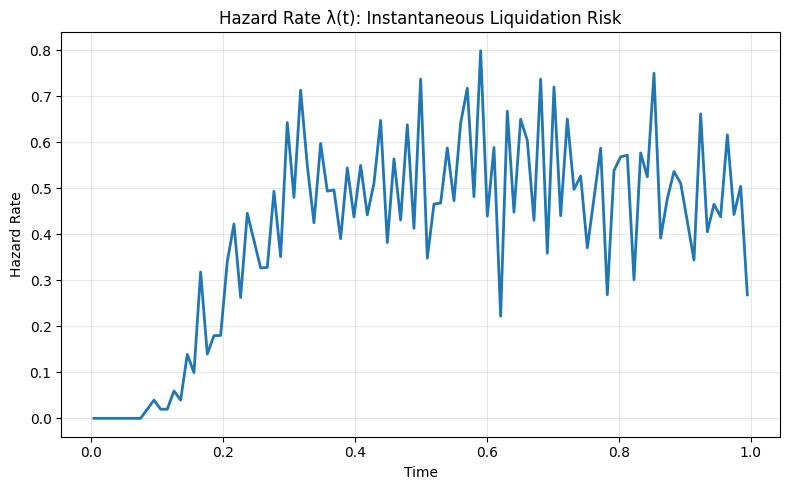

In [ ]:
T = params["T"]
t_grid = np.linspace(0, T, 100)
dt = t_grid[1] - t_grid[0]

# event indicator
event = liquidated.copy()

# replace NaN liquidation times with censoring time T
event_time = np.where(np.isnan(tau), T, tau)

hazard = []
midpoints = []

for i in range(len(t_grid) - 1):
    left = t_grid[i]
    right = t_grid[i + 1]

    # paths still at risk at the beginning of the interval
    at_risk = event_time >= left

    # liquidation events occurring in this interval
    events = event & (event_time >= left) & (event_time < right)

    n_risk = at_risk.sum()
    n_events = events.sum()

    if n_risk > 50:
        hazard.append(n_events / n_risk / dt)
    else:
        hazard.append(np.nan)

    midpoints.append(0.5 * (left + right))

hazard = np.array(hazard)
midpoints = np.array(midpoints)

plt.figure(figsize=(8, 5))
plt.plot(midpoints, hazard, linewidth=2)
plt.title("Hazard Rate λ(t): Instantaneous Liquidation Risk")
plt.xlabel("Time")
plt.ylabel("Hazard Rate")
plt.grid(alpha=0.3)
plt.tight_layout()

# ✅ SAVE HERE
plt.savefig(
    "figures/fig5_hazard_rate_λ(t).png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import numpy as np

def estimate_hf_hazard(results, n_bins=25, hf_min=1.0, hf_max=None):
    """
    Estimate conditional hazard rate λ(HF):
        P(liquidation in next dt | HF_t ≈ h) / dt

    Expected keys in results:
        - results["HF_paths"]
        - results["liquidation_times"]
        - results["liquidated"]
        - results["time_grid"]
    """

    hf_paths = results["HF_paths"]
    liquidation_times = results["liquidation_times"]
    liquidated = results["liquidated"]
    time_grid = results["time_grid"]

    n_paths, n_cols = hf_paths.shape
    n_steps = n_cols - 1
    dt = time_grid[1] - time_grid[0]
    T = time_grid[-1]

    # Convert liquidation times to breach indices
    breach_idx = np.full(n_paths, n_steps + 1, dtype=int)

    # only liquidated paths have a valid first breach time
    breach_idx[liquidated] = np.round(liquidation_times[liquidated] / dt).astype(int)

    if hf_max is None:
        hf_max = np.nanmax(hf_paths)

    bin_edges = np.linspace(hf_min, hf_max, n_bins + 1)
    counts = np.zeros(n_bins, dtype=int)
    events = np.zeros(n_bins, dtype=int)

    # loop over time steps k = 0, ..., n_steps-1
    for k in range(n_steps):
        hf_now = hf_paths[:, k]

        # path is still alive at time k if first breach occurs after k
        alive_now = breach_idx > k

        # liquidation occurs in next step if breach is exactly k+1
        event_next = breach_idx == (k + 1)

        valid = alive_now & np.isfinite(hf_now)

        hf_valid = hf_now[valid]
        event_valid = event_next[valid]

        bin_idx = np.digitize(hf_valid, bin_edges) - 1
        in_range = (bin_idx >= 0) & (bin_idx < n_bins)

        hf_valid = hf_valid[in_range]
        event_valid = event_valid[in_range]
        bin_idx = bin_idx[in_range]

        for b in range(n_bins):
            mask = bin_idx == b
            if np.any(mask):
                counts[b] += mask.sum()
                events[b] += event_valid[mask].sum()

    hazard = np.full(n_bins, np.nan)
    valid_bins = counts > 0
    hazard[valid_bins] = events[valid_bins] / counts[valid_bins] / dt

    hf_mid = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    return hf_mid, hazard, counts, events




In [ ]:
hf_mid, hazard_hf, counts, events = estimate_hf_hazard(
    results=results,
    n_bins=20,
    hf_min=1.0,
    hf_max=2.5
)

print("hf_mid defined:", hf_mid is not None)
print("hazard_hf defined:", hazard_hf is not None)
print("counts defined:", counts is not None)



hf_mid defined: True
hazard_hf defined: True
counts defined: True


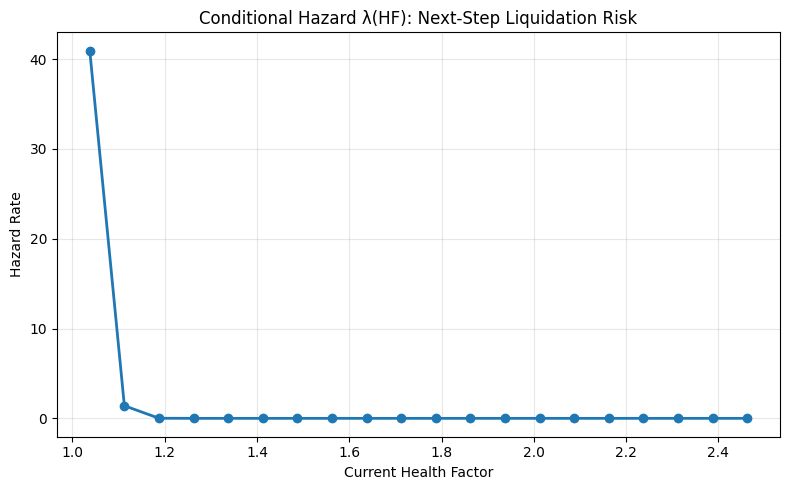

In [ ]:
hazard_plot = hazard_hf.copy()
hazard_plot[counts < 100] = np.nan   # hide bins with too little data

plt.figure(figsize=(8, 5))
plt.plot(hf_mid, hazard_plot, marker="o", linewidth=2)

plt.title("Conditional Hazard λ(HF): Next-Step Liquidation Risk")
plt.xlabel("Current Health Factor")
plt.ylabel("Hazard Rate")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

